# Clonnage

In [14]:
!git clone https://github.com/mernaro/pipeline.git
!mv pipeline/* .
!rm -rf pipeline

Cloning into 'pipeline'...
remote: Enumerating objects: 303, done.
remote: Counting objects: 100% (303/303), done.
remote: Compressing objects: 100% (278/278), done.
remote: Total 303 (delta 22), reused 302 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (303/303), 49.66 MiB | 44.80 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Updating files: 100% (739/739), done.
mv: cannot move 'pipeline/experiments' to './experiments': Directory not empty
mv: cannot move 'pipeline/models' to './models': Directory not empty
mv: cannot move 'pipeline/src' to './src': Directory not empty


# Install & Import

In [ ]:
!pip install git+https://github.com/akhaten/lasp.git@d38b9168d2ec86f26c084dbae167d4eb07d75876

  Cloning https://github.com/akhaten/lasp.git (to revision d38b9168d2ec86f26c084dbae167d4eb07d75876) to /tmp/pip-req-build-sp6amfoe
  Running command git clone --filter=blob:none --quiet https://github.com/akhaten/lasp.git /tmp/pip-req-build-sp6amfoe
  Running command git rev-parse -q --verify 'sha^d38b9168d2ec86f26c084dbae167d4eb07d75876'
  Running command git fetch -q https://github.com/akhaten/lasp.git d38b9168d2ec86f26c084dbae167d4eb07d75876
  Running command git checkout -q d38b9168d2ec86f26c084dbae167d4eb07d75876
  Resolved https://github.com/akhaten/lasp.git to commit d38b9168d2ec86f26c084dbae167d4eb07d75876
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.9 MB/s eta 0:00:00
  Created wheel for lasp: filename=lasp-0.1.0-py3-none-any.whl size=17710 sha256=49c9cb5737cf537119bf5e63d0710df2d146dfc90741d55007b4edf28695d3b5
  Stored in directory: /root/.cac

In [7]:
from models.Unfolding import Unfolding
from src.PipeTrainer import PipeTrainer
from src.PipEval import evaluation
from src.datasets.ImageDataset import ImageDataset, get_batch_with_variable_size_image
from src.utils.UtilsLauncher import json_reader, data_config_reader, add_dated_folder, json_saver
from torch.utils import data
from torch.optim import Adam, AdamW
import torch
import torch.nn as nn
import torch.nn
import argparse
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Config

In [9]:
config = {
    "data": {
        "data_dir": "./data/dataset1",
        "train_instances": 67,
        "validation_instances": 14,
        "evaluation_instances": 15
    },
    "model": {
        "params": {
            "alpha": {
                "initialize": 1.0,
                "is_learnable": True
            },
            "beta0": {
                "initialize": 0.1,
                "is_learnable": True
            },
            "beta1": {
                "initialize": 0.1,
                "is_learnable": True
            },
            "sigma": {
                "initialize": 0.2,
                "is_learnable": True
            },
            "nb_intermediate_channels": 1,
            "nb_iteration": 5,
            "kernel_size": [
                5,
                5
            ],
            "taylor": {
                "nb_iteration": 2,
                "kernel_size": [
                    5,
                    5
                ]
            },
            "taylor_generic": "new_taylor"
        }
    },
    "train": {
        "nb_epochs": 1000,
        "learning_rate": 0.001,
        "lr_unfolding": 0.001,
        "lr_unet": 0.0001,
        "patience": 200,
        "training_batch_size": 32,
        "validation_batch_size": 32,
        "min_delta": 0.0001,
        "w_sr": 1,
        "w_seg": 0.5,
        "unet_dropout": 0.3,
        "grad_clip": 1,
        "weight_decay": 0.01
    },
    "output_dir": "./experiments_notebook/",
    "model_dir": "./experiments/configs/pipeline.pth"
}

# Launcher

In [16]:
print("=== Lancement du script principal ===")
action = "test"

data_config = config["data"]
train_config = config["train"]
output_dir = add_dated_folder(config["output_dir"])
data_dir, train_instances, validation_instances, evaluation_instances = data_config_reader(config)

print("Initialisation des datasets...")
train_dataset      = ImageDataset(train_instances,      "train", data_dir=data_dir)
val_dataset        = ImageDataset(validation_instances, "val",   data_dir=data_dir)
evaluation_dataset = ImageDataset(evaluation_instances, "test",  data_dir=data_dir)
train_loader = data.DataLoader(
    train_dataset,
    batch_size = train_config["training_batch_size"],
    collate_fn = get_batch_with_variable_size_image,
    shuffle    = True,
)
val_loader = data.DataLoader(
    val_dataset,
    batch_size = train_config["validation_batch_size"],
    collate_fn = get_batch_with_variable_size_image,
    shuffle    = True,
)
evaluation_loader = data.DataLoader(
    evaluation_dataset,
    batch_size = train_config["validation_batch_size"],
    collate_fn = get_batch_with_variable_size_image,
    shuffle    = False,
)
print(f"Datasets initialises : train({len(train_dataset)}), "
      f"validation({len(val_dataset)}), evaluation({len(evaluation_dataset)}).")

# Lecture des hyperparametres depuis config
lr_unfolding = train_config.get("lr_unfolding", train_config["learning_rate"])
lr_unet      = train_config.get("lr_unet",      train_config["learning_rate"])
weight_decay = train_config.get("weight_decay", None)
nb_epochs    = train_config["nb_epochs"]
patience     = train_config["patience"]
min_delta    = train_config["min_delta"]
w_sr         = train_config.get("w_sr",        1.0)
w_seg        = train_config.get("w_seg",        1.0)
unet_dropout = train_config.get("unet_dropout", 0.1)
grad_clip    = train_config.get("grad_clip",    1.0)
batch_train  = train_config["training_batch_size"]
batch_val    = train_config["validation_batch_size"]

# NOTE: The 'args' object (e.g., from argparse) is not defined in this cell.
# If 'args' is not defined, this code will raise a NameError.
# Assuming 'args' will be defined elsewhere or provided.
if action == "train":
    print("Initialisation du modele Unfolding...")
    unfolding_model = Unfolding.from_config(config)
    print("Modele Unfolding initialise.")

    print("Initialisation du PipeTrainer...")
    trainer = PipeTrainer(
        unfolding_model = unfolding_model,
        unet_dropout    = unet_dropout,
        w_sr            = w_sr,
        w_seg           = w_seg,
        grad_clip       = grad_clip,
    )
    print("PipeTrainer initialise.")

    # Deux optimiseurs separes
    print("Initialisation des optimiseurs et de la fonction de perte...")
    if weight_decay is None:
        optimizer_unfolding = Adam(trainer.unfolding.parameters(), lr=lr_unfolding)
        optimizer_unet      = Adam(trainer.unet.parameters(),      lr=lr_unet)
    else:
        optimizer_unfolding = AdamW(trainer.unfolding.parameters(), lr=lr_unfolding, weight_decay=weight_decay)
        optimizer_unet      = AdamW(trainer.unet.parameters(),      lr=lr_unet,      weight_decay=weight_decay)
        print("Optimiseurs AdamW avec weight decay.")

    criterion = nn.MSELoss()
    print("Optimiseurs et fonction de perte initialises.")

    print(f"Debut de l entrainement pour {nb_epochs} epoques...")
    trainer.train(
        optimizer_unfolding = optimizer_unfolding,
        optimizer_unet      = optimizer_unet,
        criterion           = criterion,
        train_loader        = train_loader,
        batch_size_train    = batch_train,
        validation_loader   = val_loader,
        batch_size_val      = batch_val,
        nb_epoch            = nb_epochs,
        patience            = patience,
        output_dir          = output_dir,
        min_delta           = min_delta,
        phase1_epochs       = 200,
        phase2_epochs       = 200,
        w_seg_max           = 1,
        lr_unfolding_p1     = 1e-3,
        lr_unet_p2          = 1e-4,
        lr_unfolding_p3     = 1e-4,
        lr_unet_p3          = 1e-5,
    )

    json_saver(output_dir, config)
    print("=== Entrainement termine avec succes ===")

elif action == "test":
    print("Chargement des modeles pour l evaluation...")
    device = "cuda" if torch.cuda.is_available() else "cpu"

    unfolding_model = Unfolding.from_config(config)
    trainer = PipeTrainer(
        unfolding_model = unfolding_model,
        unet_dropout    = unet_dropout,
        w_sr            = w_sr,
        w_seg           = w_seg,
    )

    ckpt = torch.load(config["model_dir"], map_location=device)
    trainer.unfolding.load_state_dict(ckpt["unfolding_state"])
    trainer.unet.load_state_dict(ckpt["unet_state"])
    print(f"Modeles charges depuis {config['model_dir']} (device : {device}).")

    print("Debut de l evaluation du pipeline...")
    evaluation(trainer, evaluation_loader, output_dir)
    print("=== Evaluation terminee avec succes ===")

=== Lancement du script principal ===
Initialisation des datasets...
[ImageDataset] Masques charges depuis ./data/dataset1/train/masques
[ImageDataset] Masques charges depuis ./data/dataset1/val/masques
[ImageDataset] Masques charges depuis ./data/dataset1/test/masques
Datasets initialises : train(67), validation(14), evaluation(15).
Chargement des modeles pour l evaluation...
[PipeTrainer] device=cpu | w_sr=1 | w_seg=0.5
[PipeTrainer] UNet params : 579,745
Modeles charges depuis ./experiments/configs/pipeline.pth (device : cpu).
Debut de l evaluation du pipeline...

Fichier de metriques sauvegarde : ./experiments_notebook/2026-03-10_00-45/metrics.csv
=== Evaluation terminee avec succes ===


# Résultats

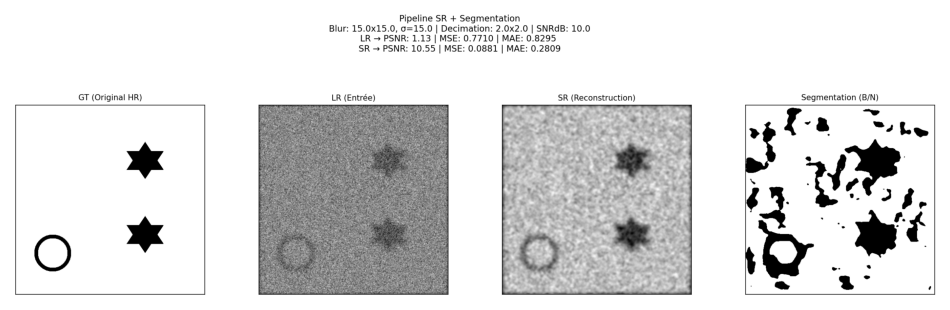

In [21]:
#Mettre le path de save écris au dessus ex : ./experiments_notebook/2026-03-05_08-49/
path_save = "./experiments_notebook/2026-03-10_00-45/"
id_img = 10 #Choisir l'image que l'on veut

total_path = f"{path_save}{id_img}_eval.png"

img = mpimg.imread(total_path)
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.show()